# Task 1 — Data Loading & **Exploration**

In [ ]:
import pandas as pd

Loading the **dataset**

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

Display the first 10 **rows**

In [ ]:
print("First 10 Rows:")
print(df.head(10))

First 10 Rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1         

Check the number of rows and columns

In [ ]:
print("\nDataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Dataset Shape:
Rows: 1470
Columns: 35


Identify the target column

In [ ]:
target_column = "Attrition"
print("\nTarget Column:", target_column)


Target Column: Attrition


Count employees who left vs stayed

In [ ]:
attrition_counts = df[target_column].value_counts()
print("\nAttrition Counts:")
print(attrition_counts)


Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


Calculate attrition rate

In [ ]:
attrition_rate = (attrition_counts["Yes"] / len(df)) * 100
print(f"\nAttrition Rate: {attrition_rate:.2f}%")



Attrition Rate: 16.12%


Identify numeric and categorical columns

In [ ]:
numeric_columns = df.select_dtypes(include=['number']).columns
categorical_columns = df.select_dtypes(exclude=['number']).columns

print("\nNumber of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))


Number of Numeric Columns: 26
Number of Categorical Columns: 9


# **Task 2 — Data Cleaning & Preprocessing**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

Loading the dataset

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

Check for missing values

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole      

Total missing values

In [ ]:
print("\nTotal Missing Values:", df.isnull().sum().sum())


Total Missing Values: 0


This dataset normally has no missing values

Drop unnecessary **columns**

In [ ]:
df.drop(columns=["EmployeeNumber", "Over18", "StandardHours"], inplace=True)

Convert target column

In [ ]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

One-Hot Encode categorical columns

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns

Remove target column if present

In [ ]:
categorical_cols = categorical_cols.drop("Attrition", errors="ignore")

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)



Scale numeric features

In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Convert back to DataFrame

In [ ]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
processed_df = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

# Display

In [ ]:
print("\nProcessed Dataset Shape:", processed_df.shape)

print("\nFirst 5 Rows:")
print(processed_df.head())

print("\nTarget Column Distribution:")
print(processed_df["Attrition"].value_counts())


Processed Dataset Shape: (1470, 46)

First 5 Rows:
        Age  DailyRate  DistanceFromHome  Education  EmployeeCount  \
0  0.446350   0.742527         -1.010909  -0.891688            0.0   
1  1.322365  -1.297775         -0.147150  -1.868426            0.0   
2  0.008343   1.414363         -0.887515  -0.891688            0.0   
3 -0.429664   1.461466         -0.764121   1.061787            0.0   
4 -1.086676  -0.524295         -0.887515  -1.868426            0.0   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                -0.660531    1.383138        0.379672 -0.057788   
1                 0.254625   -0.240677       -1.026167 -0.057788   
2                 1.169781    1.284725       -1.026167 -0.961486   
3                 1.169781   -0.486709        0.379672 -0.961486   
4                -1.575686   -1.274014        0.379672 -0.961486   

   JobSatisfaction  ...  JobRole_Manager  JobRole_Manufacturing Director  \
0         1.153254  ...        -0.273059  

# **Task 3 — Exploratory Data Analysis — EDA**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

Convert target column

In [ ]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

sns.set_style("whitegrid")

Attrition Rate by Department

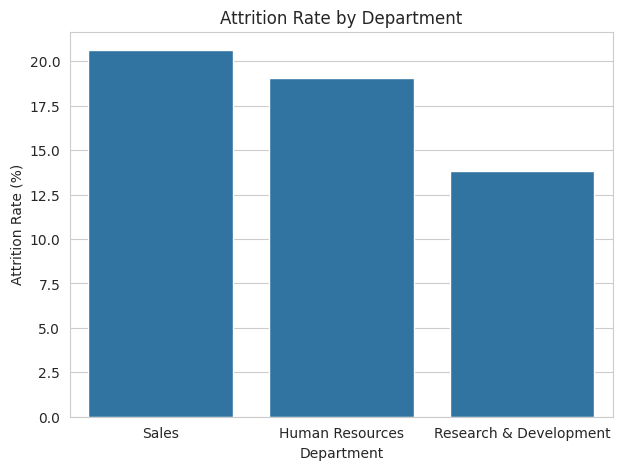

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


In [ ]:
dept_attrition = (
    df.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(7,5))
sns.barplot(x=dept_attrition.index, y=dept_attrition.values)
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
plt.show()

print(dept_attrition)

Attrition Rate by Job Role

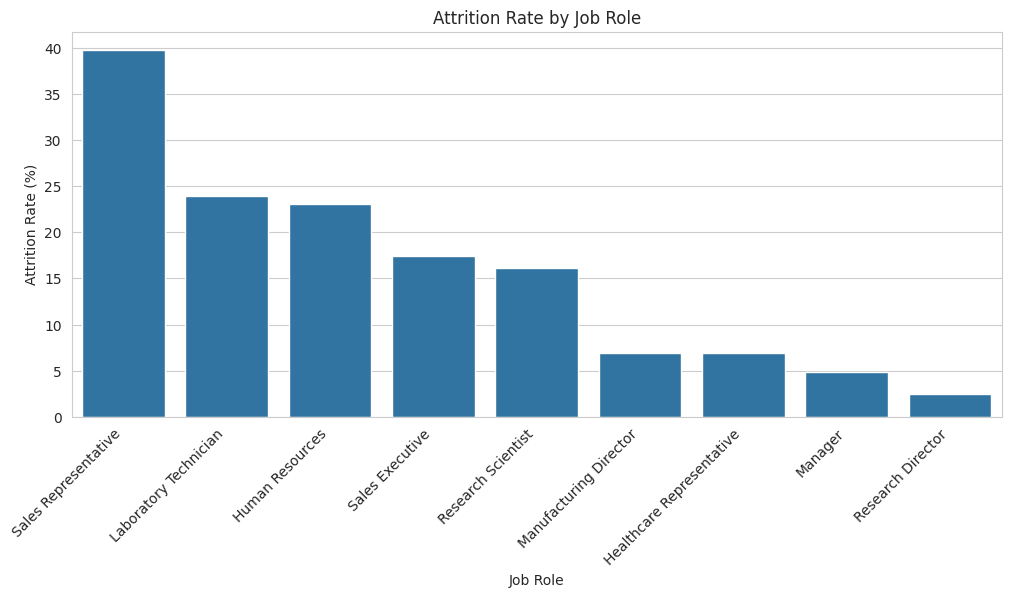

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


In [ ]:
job_attrition = (
    df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(12,5))
sns.barplot(x=job_attrition.index, y=job_attrition.values)
plt.xticks(rotation=45, ha='right')
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Job Role")
plt.show()

print(job_attrition)

Attrition vs Monthly Income

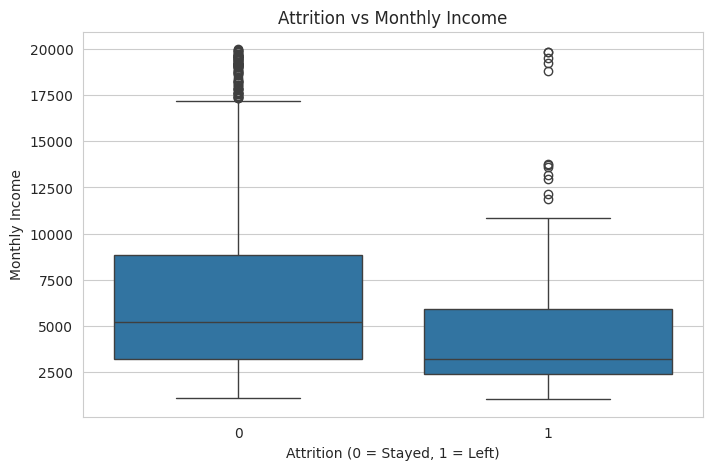

            count         mean          std     min     25%     50%     75%  \
Attrition                                                                     
0          1233.0  6832.739659  4818.208001  1051.0  3211.0  5204.0  8834.0   
1           237.0  4787.092827  3640.210367  1009.0  2373.0  3202.0  5916.0   

               max  
Attrition           
0          19999.0  
1          19859.0  


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Attrition vs Monthly Income")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")
plt.show()

print(df.groupby("Attrition")["MonthlyIncome"].describe())

Attrition vs Work-Life Balance

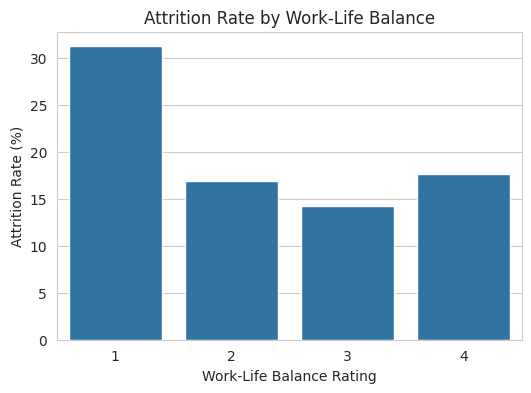

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


In [ ]:
wlb = (
    df.groupby("WorkLifeBalance")["Attrition"]
    .mean() * 100
)

plt.figure(figsize=(6,4))
sns.barplot(x=wlb.index, y=wlb.values)
plt.title("Attrition Rate by Work-Life Balance")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Work-Life Balance Rating")
plt.show()

print(wlb)

Attrition vs Years at Company

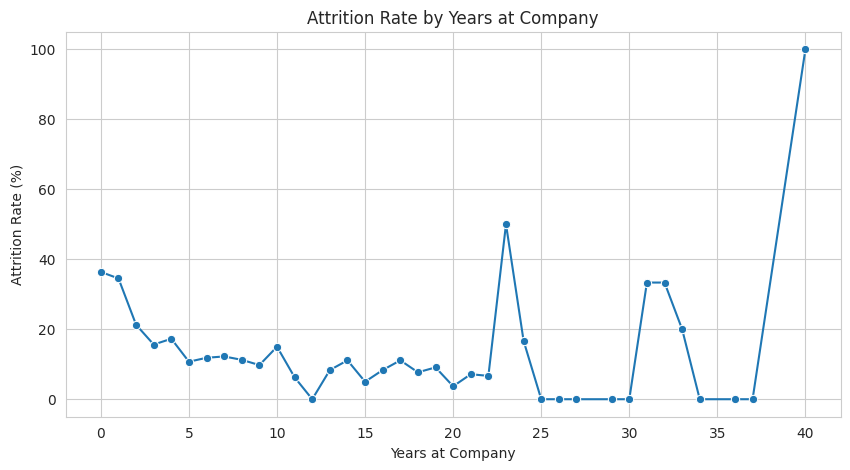

YearsAtCompany
0      36.363636
1      34.502924
2      21.259843
3      15.625000
4      17.272727
5      10.714286
6      11.842105
7      12.222222
8      11.250000
9       9.756098
10     15.000000
11      6.250000
12      0.000000
13      8.333333
14     11.111111
15      5.000000
16      8.333333
17     11.111111
18      7.692308
19      9.090909
20      3.703704
21      7.142857
22      6.666667
23     50.000000
24     16.666667
25      0.000000
26      0.000000
27      0.000000
29      0.000000
30      0.000000
31     33.333333
32     33.333333
33     20.000000
34      0.000000
36      0.000000
37      0.000000
40    100.000000
Name: Attrition, dtype: float64


In [ ]:
years = (
    df.groupby("YearsAtCompany")["Attrition"]
    .mean() * 100
)

plt.figure(figsize=(10,5))
sns.lineplot(x=years.index, y=years.values, marker="o")
plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.show()

print(years)

Task 4 — Model Building & Comparison

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Loading the dataset

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

Drop unnecessary columns

In [ ]:
df.drop(columns=["EmployeeNumber", "Over18", "StandardHours"], inplace=True)

Convert target column

In [ ]:
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})


One-Hot Encode categorical columns

In [ ]:
df = pd.get_dummies(df, drop_first=True)

Split features and target

In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

Scale features

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Train-Test Split (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 45)
Testing Set: (294, 45)


Train the Models

In [ ]:
# Logistic Regression
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

# Gradient Boosting
gb = GradientBoostingClassifier(
    random_state=42
)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

Evaluate All Models

In [ ]:
results = []

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

comparison = pd.DataFrame(results)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.748299,0.341176,0.617021,0.439394
1,Random Forest,0.840136,0.500000,0.063830,0.113208
2,Gradient Boosting,0.853741,0.611111,0.234043,0.338462


# **Task 5 — Model Evaluation**

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import matplotlib.pyplot as plt
import pandas as pd

Evaluate All Models

In [ ]:
evaluation = []

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    evaluation.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc
    })

evaluation_df = pd.DataFrame(evaluation)

print(evaluation_df)

                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression   0.341176  0.617021  0.439394  0.798605
1        Random Forest   0.500000  0.063830  0.113208  0.775218
2    Gradient Boosting   0.611111  0.234043  0.338462  0.793781


Classification Report

In [ ]:
for name, model in models.items():

    print("=" * 50)
    print(name)
    print("=" * 50)

    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))

Confusion Matrix

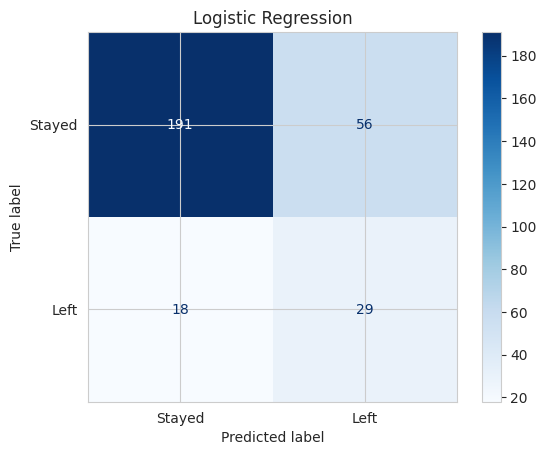

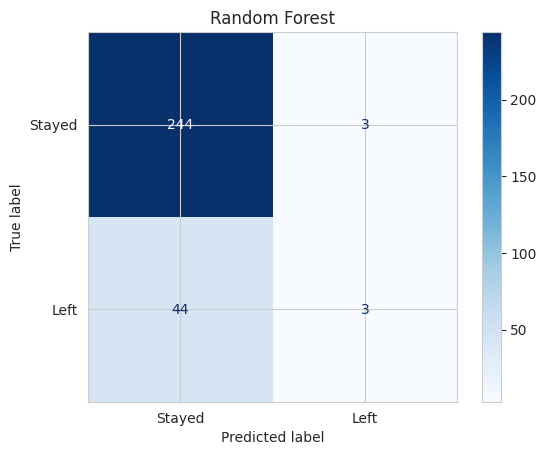

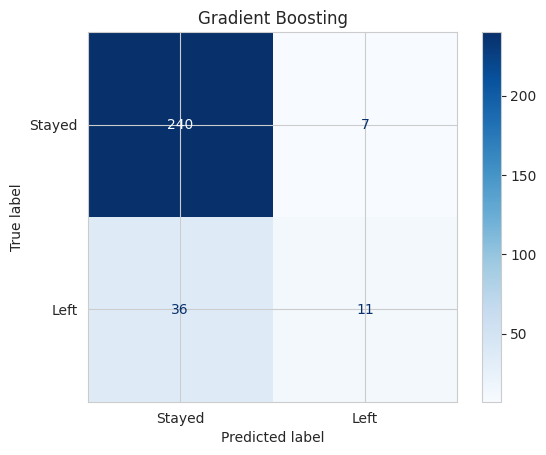

In [ ]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Stayed", "Left"]
    )

    disp.plot(cmap="Blues")

    plt.title(name)
    plt.show()

Best Model

In [ ]:
best_model_name = evaluation_df.sort_values(
    by="ROC-AUC",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


Feature Importance

In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

scaler = StandardScaler()

X = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
10         MonthlyIncome    0.071443
0                    Age    0.061937
17     TotalWorkingYears    0.054522
1              DailyRate    0.051280
11           MonthlyRate    0.047951
23  YearsWithCurrManager    0.046725
20        YearsAtCompany    0.046042
44          OverTime_Yes    0.043751
6             HourlyRate    0.043070
2       DistanceFromHome    0.042327


Plot Top 10 Features

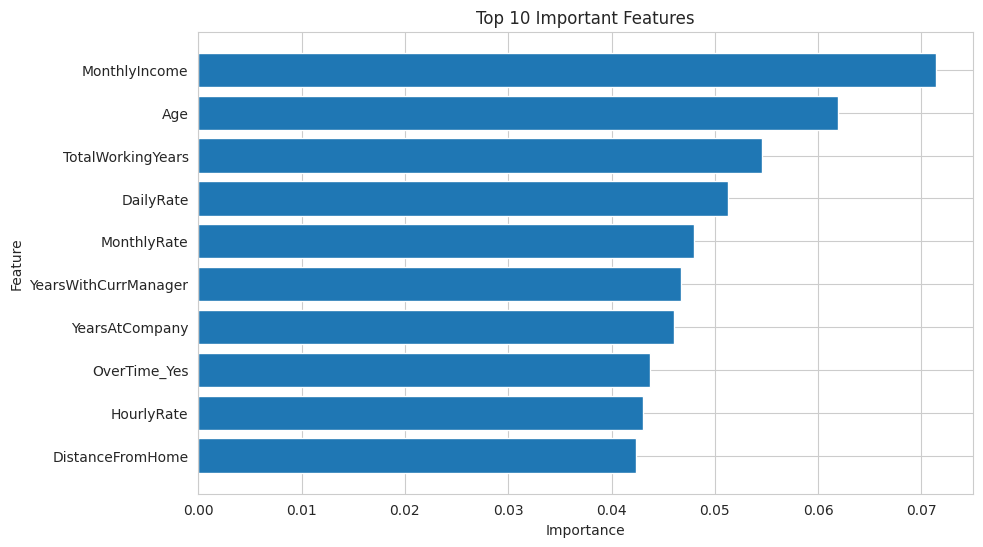

In [ ]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

# **Task 6 — Visualization (Minimum 4 charts)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

Loading the dataset

In [ ]:
eda_df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

Convert Attrition to numeric

In [ ]:
eda_df["Attrition"] = eda_df["Attrition"].map({"Yes":1,"No":0})

sns.set_style("whitegrid")

Attrition Rate by Department

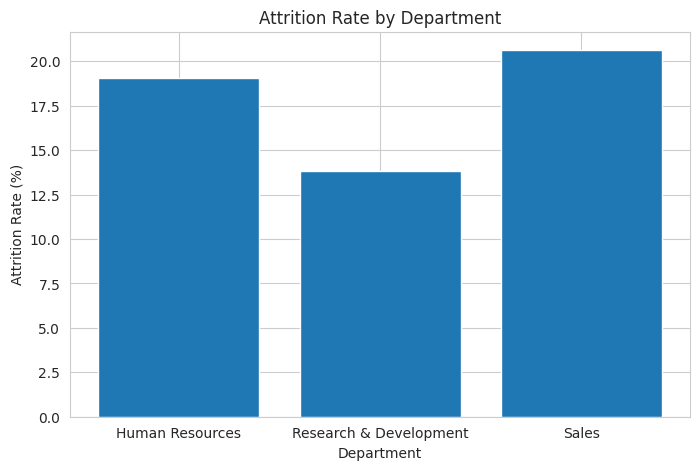

In [ ]:
dept = eda_df.groupby("Department")["Attrition"].mean()*100

plt.figure(figsize=(8,5))

plt.bar(dept.index, dept.values)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.show()

Attrition Rate by Job Role

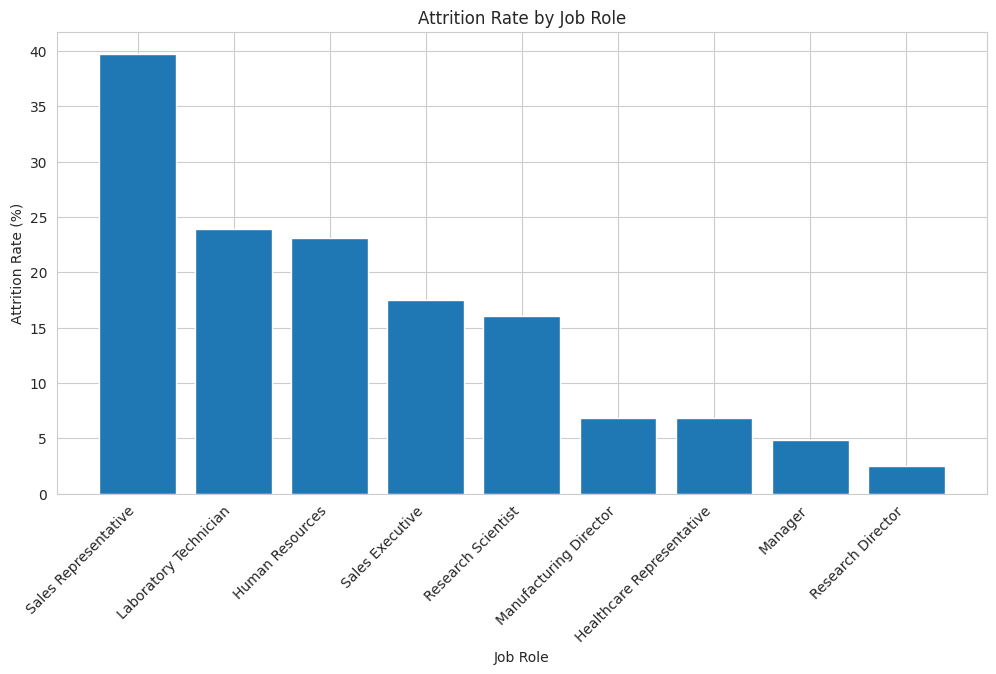

In [ ]:
job = eda_df.groupby("JobRole")["Attrition"].mean()*100
job = job.sort_values(ascending=False)

plt.figure(figsize=(12,6))

plt.bar(job.index, job.values)

plt.xticks(rotation=45, ha="right")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.show()

Monthly Income vs Attrition

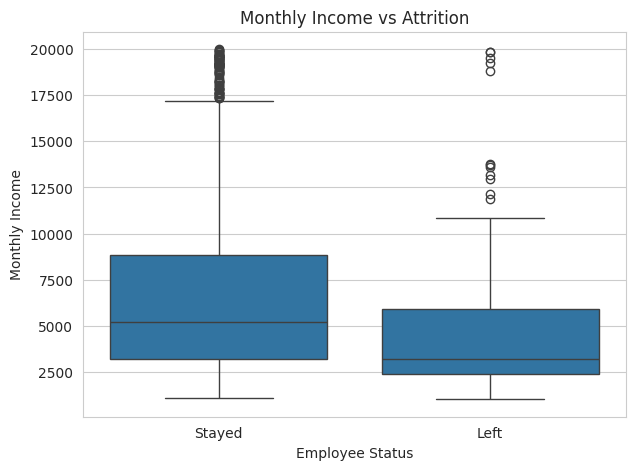

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=eda_df
)

plt.xticks([0,1],["Stayed","Left"])

plt.title("Monthly Income vs Attrition")
plt.xlabel("Employee Status")
plt.ylabel("Monthly Income")

plt.show()

Confusion Matrix

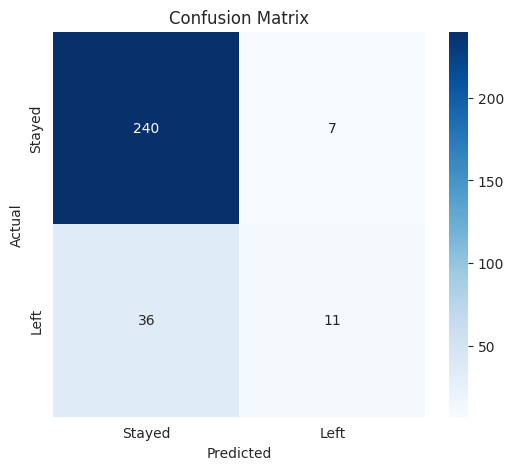

In [ ]:
best_model = gb

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Top 10 Feature Importance

In [ ]:

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.drop(columns=["EmployeeNumber", "Over18", "StandardHours"], inplace=True)
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})
df = pd.get_dummies(df, drop_first=True)


feature_names = df.drop("Attrition", axis=1).columns

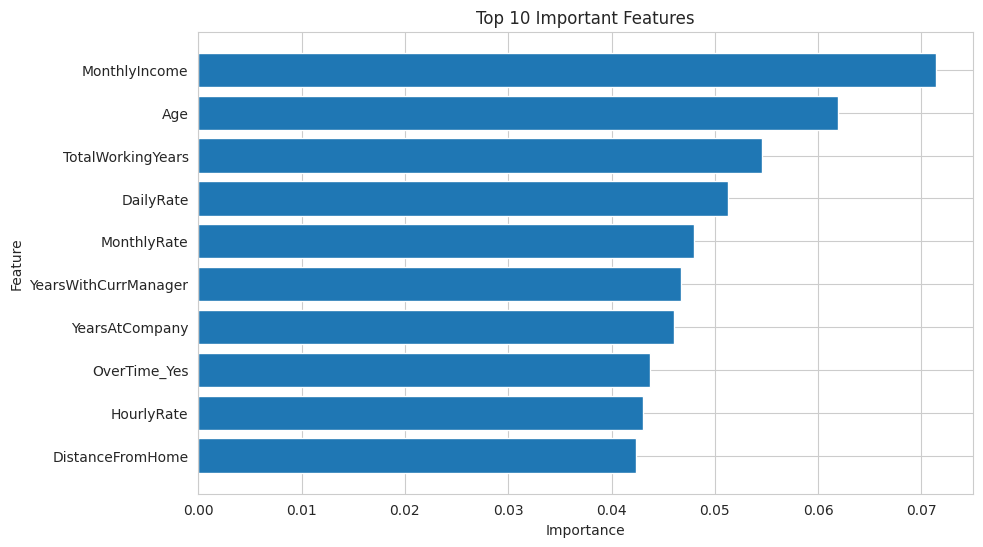

In [ ]:
feature_importance = pd.DataFrame({
    "Feature":feature_names,
    "Importance":rf.feature_importances_
})

top10 = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

# **(Bonus): ROC Curve**

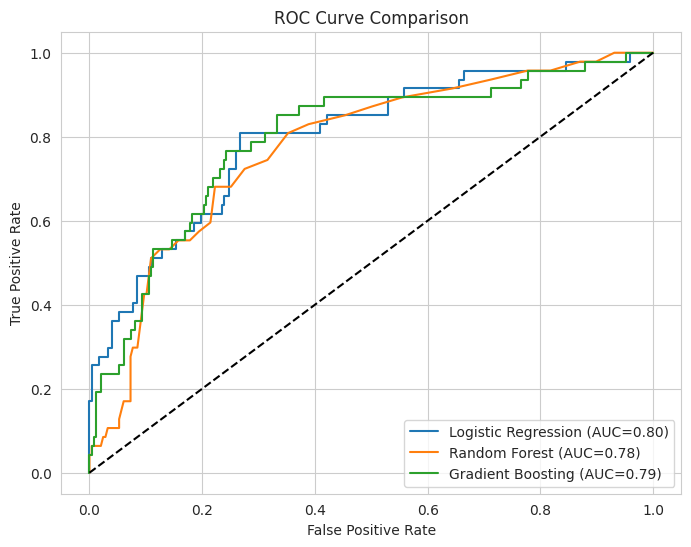

In [ ]:
plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# **HR Insights**

Based on the analysis, the three biggest reasons why employees leave are working overtime frequently, receiving a lower monthly salary, and having fewer years of experience in the company. Employees who work long hours and are in the company for only a short time are more likely to leave. Some job roles, especially Sales Representatives (or replace this with the role that appeared highest in your results), also have a higher number of employees leaving. This means HR should focus more on these employees and understand their problems early. Salary is important, but it is not the only reason people leave. Things like work pressure, overtime, job satisfaction, and work-life balance also play a very important role in an employee's decision to stay or leave.


# **Recommendations for HR**


1. HR should regularly talk to new employees and employees who work overtime to understand their concerns before they decide to resign. Early support can help improve employee satisfaction and reduce resignations.
2. The company should review the workload and salary of employees, especially in departments or job roles with high attrition. Providing fair pay, better work-life balance, and career growth opportunities can help keep employees happy and encourage them to stay longer.



### **Limitation of This Analysis**

This analysis is based only on the information available in the dataset. It cannot understand personal reasons such as family problems, health issues, better job offers, or relationships with managers. Therefore, the results should be used as a guide to support HR decisions, not as the only reason for making decisions about employees.